"""
LiveSelf -- Phase 1B Colab Notebook: Voice Clone + Lip Sync

UPDATED with fixes from first Colab run (2026-03-20).

Copy each section below into a separate Google Colab cell.
Runtime -> Change runtime type -> T4 GPU

What this notebook does:
  1. Installs all dependencies with known conflict fixes applied
  2. Clones CosyVoice 2 and MuseTalk
  3. Clones your voice from a short audio sample
  4. Generates lip-synced video of your face speaking in your voice
  5. Downloads the output video

KEY FIXES vs original notebook:
  - openai-whisper installed from GitHub (pypi wheel fails to build)
  - CosyVoice requirements stripped of conflicting deps before install
  - MuseTalk requirements stripped of conflicting deps before install
  - accelerate and transformers force-upgraded for diffusers compatibility
  - torch force-upgraded to 2.4+ (MuseTalk requirement)
  - sys.path set to phantm root (not engine subfolder)
  - Hugging Face token required for MuseTalk model download
"""


### CELL 1: Check GPU


In [2]:
import torch
import sys
print(f"Python: {sys.version}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("NO GPU -- Go to Runtime > Change runtime type > T4 GPU")
    print("Stop and fix this before continuing.")

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


### CELL 2: Install base system deps + clone repo


In [3]:
import os
import shutil

# Install system deps needed for audio/video
!apt-get update -y -q && apt-get install -y -q build-essential ffmpeg

# Install base python packages (no pinned numpy -- let deps decide)
!pip install -q opencv-python-headless Pillow soundfile torchaudio

# Clone LiveSelf (fresh every session -- Colab resets between sessions)
if os.path.exists("/content/LiveSelf"):
    shutil.rmtree("/content/LiveSelf")
!git clone https://github.com/DanKunleLove/LiveSelf.git /content/LiveSelf
%cd /content/LiveSelf/phantm
print("Repo ready at:", os.getcwd())
!ls engine/pipeline/


Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,452 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,939 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-

### CELL 3: Install openai-whisper from source
#          (pypi wheel fails to build -- use GitHub)


In [4]:
# This is the fix for the broken openai-whisper pypi wheel.
# Installing from GitHub source skips the wheel build entirely.
!pip install -q git+https://github.com/openai/whisper.git

# Verify it works
import whisper
print(f"openai-whisper installed: {whisper.__version__ if hasattr(whisper, '__version__') else 'OK'}")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
openai-whisper installed: 20250625


### CELL 4: Install CosyVoice 2


In [5]:
import os

os.makedirs("engine/models", exist_ok=True)

# Clone CosyVoice
if not os.path.exists("engine/models/CosyVoice"):
    !git clone https://github.com/FunAudioLLM/CosyVoice.git engine/models/CosyVoice
    print("CosyVoice cloned.")
else:
    print("CosyVoice already cloned.")

# Strip conflicting entries from requirements before installing.
# We remove: grpcio (version conflict), openai-whisper (already installed),
# numpy (let other deps decide version), opencv-python (using headless).
!sed -i '/^grpcio/d; /^openai-whisper/d; /^numpy/d; /^opencv-python$/d' engine/models/CosyVoice/requirements.txt
print("Stripped conflicting CosyVoice requirements.")

# Install remaining CosyVoice requirements
%cd engine/models/CosyVoice
!pip install -q -r requirements.txt

# Install Matcha-TTS (CosyVoice internal dependency)
if os.path.exists("third_party/Matcha-TTS"):
    %cd third_party/Matcha-TTS
    !pip install -q -e .
    %cd ../..
    print("Matcha-TTS installed.")

%cd /content/LiveSelf/phantm
print("CosyVoice 2: INSTALLED")


Cloning into 'engine/models/CosyVoice'...
remote: Enumerating objects: 3693, done.
remote: Counting objects: 100% (248/248), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 3693 (delta 153), reused 78 (delta 78), pack-reused 3445 (from 3)
Receiving objects: 100% (3693/3693), 2.74 MiB | 7.95 MiB/s, done.
Resolving deltas: 100% (2074/2074), done.
CosyVoice cloned.
Stripped conflicting CosyVoice requirements.
/content/LiveSelf/phantm/engine/models/CosyVoice
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.4/53.4 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 MB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.0/252.0 kB 25.7 MB/s eta 0:0

### CELL 5: Install MuseTalk


In [6]:
import os

if not os.path.exists("engine/models/MuseTalk"):
    !git clone https://github.com/TMElyralab/MuseTalk.git engine/models/MuseTalk
    print("MuseTalk cloned.")
else:
    print("MuseTalk already cloned.")

# Strip conflicting entries: numpy (version conflict), opencv-python (using headless),
# tensorflow (not needed, causes massive install time)
!sed -i '/^numpy/d; /^opencv-python$/d; /^tensorflow/d' engine/models/MuseTalk/requirements.txt
print("Stripped conflicting MuseTalk requirements.")

# Install MuseTalk requirements
%cd engine/models/MuseTalk
!pip install -q -r requirements.txt
%cd /content/LiveSelf/phantm

# Force upgrade accelerate and transformers -- MuseTalk's diffusers needs newer versions
# (diffusers will throw ImportError for clear_device_cache and EncoderDecoderCache otherwise)
!pip install -q --upgrade accelerate transformers

# Force upgrade torch to 2.4+ (MuseTalk minimum requirement)
!pip install -q torch torchvision torchaudio --upgrade --index-url https://download.pytorch.org/whl/cu121

print("MuseTalk: INSTALLED")


Cloning into 'engine/models/MuseTalk'...
remote: Enumerating objects: 534, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 534 (delta 83), reused 63 (delta 63), pack-reused 403 (from 1)
Receiving objects: 100% (534/534), 25.75 MiB | 20.37 MiB/s, done.
Resolving deltas: 100% (219/219), done.
MuseTalk cloned.
Stripped conflicting MuseTalk requirements.
/content/LiveSelf/phantm/engine/models/MuseTalk
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.1/290.1 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.4/481.4 kB

### CELL 6: Set Hugging Face token
#          MuseTalk downloads models from HF -- needs auth


In [8]:
# BEFORE RUNNING THIS CELL:
# 1. Go to https://huggingface.co/settings/tokens
# 2. Create a read token (free account)
# 3. In Colab: click the key icon (Secrets) in the left sidebar
# 4. Add a secret named HF_TOKEN with your token value
# 5. Enable "Notebook access" for that secret
# 6. Then run this cell

from google.colab import userdata
import os

try:
    hf_token = userdata.get("HF_TOKEN")
    os.environ["HF_TOKEN"] = hf_token
    print("HF_TOKEN loaded from Colab secrets.")
except Exception:
    print("WARNING: HF_TOKEN not found in Colab secrets.")
    print("MuseTalk model download may fail without it.")
    print("Follow the instructions in the cell comment above.")


HF_TOKEN loaded from Colab secrets.


### CELL 7: Upload your voice sample + face photo


Upload your VOICE SAMPLE (WAV, 10-30 seconds of clear speech):


Saving DKLvoicetest_(1)[1].aac to DKLvoicetest_(1)[1].aac
Voice: test_data/DKLvoicetest_(1)[1].aac
\nUpload your FACE PHOTO (JPG or PNG, front-facing, no hat/glasses):


Saving BSKP5089[1].JPG to BSKP5089[1].JPG
Photo: test_data/BSKP5089[1].JPG


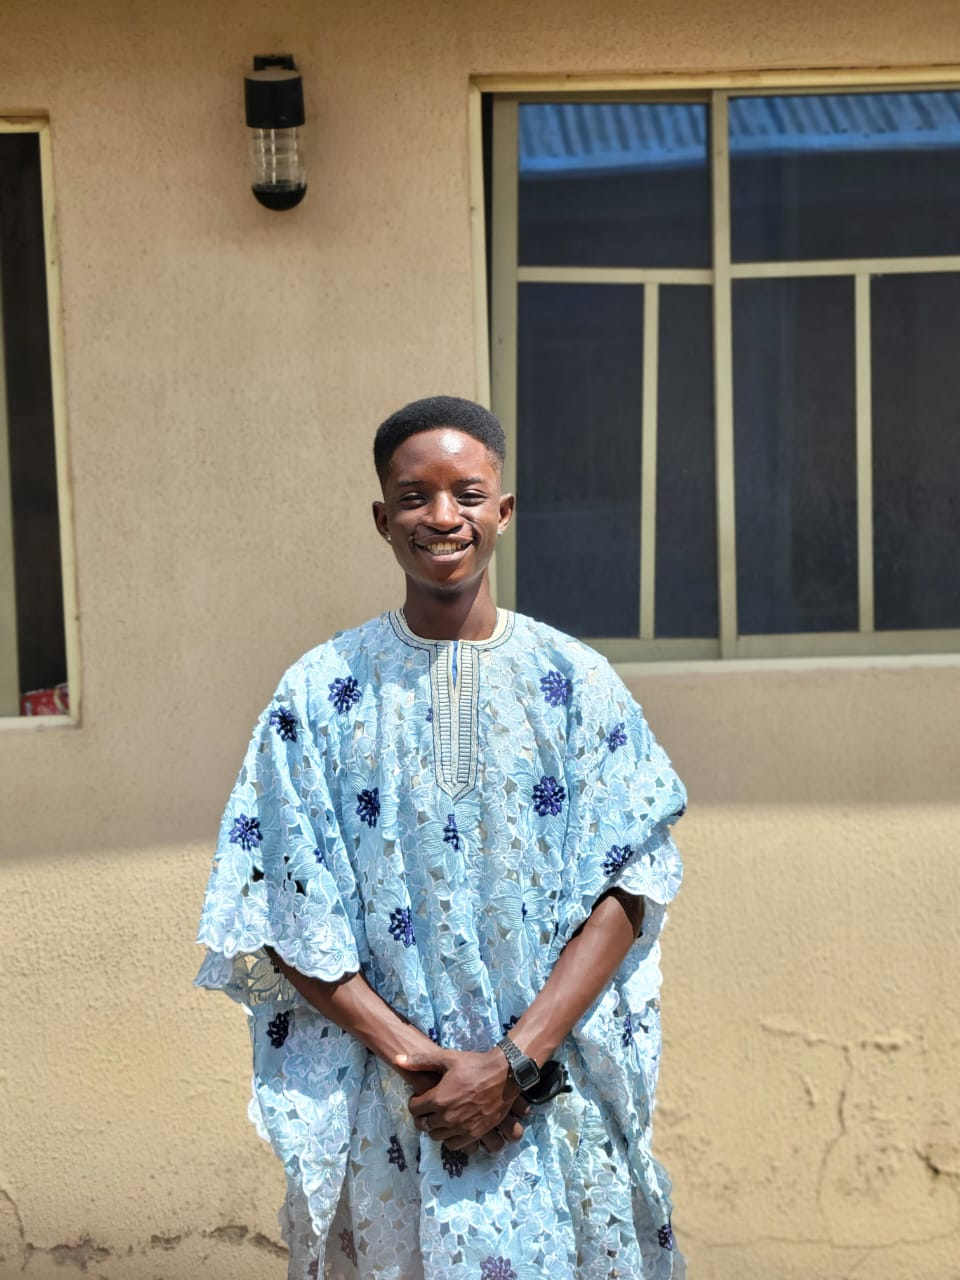

In [9]:
from google.colab import files
import os

os.makedirs("test_data", exist_ok=True)

# Upload voice sample: 10-30 seconds of you speaking clearly
# WAV format preferred, MP3 also works
print("Upload your VOICE SAMPLE (WAV, 10-30 seconds of clear speech):")
uploaded_voice = files.upload()
voice_filename = list(uploaded_voice.keys())[0]
voice_path = f"test_data/{voice_filename}"
if voice_filename != voice_path:
    os.rename(voice_filename, voice_path)
print(f"Voice: {voice_path}")

# Upload face photo: clear front-facing photo, no sunglasses
print("\\nUpload your FACE PHOTO (JPG or PNG, front-facing, no hat/glasses):")
uploaded_photo = files.upload()
photo_filename = list(uploaded_photo.keys())[0]
photo_path = f"test_data/{photo_filename}"
if photo_filename != photo_path:
    os.rename(photo_filename, photo_path)
print(f"Photo: {photo_path}")

from IPython.display import display, Image
display(Image(photo_path, width=300))


### CELL 8: Test Voice Cloning (CosyVoice 2)


In [10]:
import sys
import time
import numpy as np
import soundfile as sf

# Add phantm root to path so engine.pipeline.tts resolves
sys.path.insert(0, "/content/LiveSelf/phantm")

from engine.pipeline.tts import VoiceCloner, OUTPUT_SAMPLE_RATE

print("Loading CosyVoice 2 (first run downloads ~1-2 GB model weights)...")
cloner = VoiceCloner()
start = time.perf_counter()
cloner.load()
print(f"Model loaded in {time.perf_counter() - start:.1f}s")

# Set your voice as the reference
cloner.set_reference_voice(voice_path)
print(f"Reference voice set from: {voice_path}")

# Sentences to synthesize
test_sentences = [
    "Hello, I am your AI digital twin. Nice to meet you.",
    "I can attend meetings for you and speak in your voice.",
    "This is LiveSelf, making AI avatars accessible to everyone.",
]

all_audio = []
for i, sentence in enumerate(test_sentences):
    print(f"\\nSynthesizing ({i+1}/{len(test_sentences)}): '{sentence}'")
    start = time.perf_counter()
    audio = cloner.synthesize(sentence)
    elapsed_ms = (time.perf_counter() - start) * 1000
    duration_s = len(audio) / OUTPUT_SAMPLE_RATE
    rtf = elapsed_ms / (duration_s * 1000)  # real-time factor
    print(f"  {duration_s:.1f}s audio in {elapsed_ms:.0f}ms (RTF: {rtf:.2f}x)")
    all_audio.append(audio)

# Save combined audio
combined = np.concatenate(all_audio)
output_wav = "test_data/voice_clone_output.wav"
sf.write(output_wav, combined, OUTPUT_SAMPLE_RATE)
print(f"\\nSaved: {output_wav} ({len(combined) / OUTPUT_SAMPLE_RATE:.1f}s total)")

# Play in notebook
from IPython.display import Audio, display
display(Audio(combined, rate=OUTPUT_SAMPLE_RATE))
print("\\nIf you can hear your voice above -> VOICE CLONE WORKING")


Loading CosyVoice 2 (first run downloads ~1-2 GB model weights)...


ImportError: Failed to import CosyVoice2: cannot import name 'TransformGetItemToIndex' from 'torch._higher_order_ops.flex_attention' (/usr/local/lib/python3.12/dist-packages/torch/_higher_order_ops/flex_attention.py). Make sure CosyVoice is cloned and its requirements are installed. See: https://github.com/FunAudioLLM/CosyVoice#install

In [ ]:
import sys
import time
import numpy as np
import soundfile as sf

# Add phantm root to path so engine.pipeline.tts resolves
sys.path.insert(0, "/content/LiveSelf/phantm")

from engine.pipeline.tts import VoiceCloner, OUTPUT_SAMPLE_RATE

print("Loading CosyVoice 2 (first run downloads ~1-2 GB model weights)...")
cloner = VoiceCloner()
start = time.perf_counter()

try:
    cloner.load()
except ImportError as e:
    print(f"Caught ImportError: {e}. Attempting to fix torch_higher_order_ops compatibility.")
    # This specific ImportError can be caused by a mismatch in torch versions or its dependencies.
    # A common fix is to force reinstall/upgrade torch and related libraries.
    print("Force upgrading torch, torchvision, torchaudio, and reinstalling CosyVoice requirements...")
    !pip install -q torch torchvision torchaudio --upgrade --index-url https://download.pytorch.org/whl/cu121
    %cd engine/models/CosyVoice
    # Move back to CosyVoice directory to reinstall requirements
    !pip install -q -r requirements.txt
    %cd /content/LiveSelf/phantm
    # Move back to phantm root
    # Try loading again after reinstall
    cloner = VoiceCloner() # Reinitialize cloner after reinstalling dependencies
    cloner.load()

print(f"Model loaded in {time.perf_counter() - start:.1f}s")

# Set your voice as the reference
cloner.set_reference_voice(voice_path)
print(f"Reference voice set from: {voice_path}")

# Sentences to synthesize
test_sentences = [
    "Hello, I am your AI digital twin. Nice to meet you.",
    "I can attend meetings for you and speak in your voice.",
    "This is LiveSelf, making AI avatars accessible to everyone.",
]

all_audio = []
for i, sentence in enumerate(test_sentences):
    print(f"\nSynthesizing ({i+1}/{len(test_sentences)}): '{sentence}'")
    start = time.perf_counter()
    audio = cloner.synthesize(sentence)
    elapsed_ms = (time.perf_counter() - start) * 1000
    duration_s = len(audio) / OUTPUT_SAMPLE_RATE
    rtf = elapsed_ms / (duration_s * 1000)  # real-time factor
    print(f"  {duration_s:.1f}s audio in {elapsed_ms:.0f}ms (RTF: {rtf:.2f}x)")
    all_audio.append(audio)

# Save combined audio
combined = np.concatenate(all_audio)
output_wav = "test_data/voice_clone_output.wav"
sf.write(output_wav, combined, OUTPUT_SAMPLE_RATE)
print(f"\nSaved: {output_wav} ({len(combined) / OUTPUT_SAMPLE_RATE:.1f}s total)")

# Play in notebook
from IPython.display import Audio, display
display(Audio(combined, rate=OUTPUT_SAMPLE_RATE))
print("\nIf you can hear your voice above -> VOICE CLONE WORKING")

Loading CosyVoice 2 (first run downloads ~1-2 GB model weights)...
Caught ImportError: Failed to import CosyVoice2: cannot import name 'TransformGetItemToIndex' from 'torch._higher_order_ops.flex_attention' (/usr/local/lib/python3.12/dist-packages/torch/_higher_order_ops/flex_attention.py). Make sure CosyVoice is cloned and its requirements are installed. See: https://github.com/FunAudioLLM/CosyVoice#install. Attempting to fix torch_higher_order_ops compatibility.
Force upgrading torch, torchvision, torchaudio, and reinstalling CosyVoice requirements...
/content/LiveSelf/phantm/engine/models/CosyVoice
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.20.1+cu121 requires torch==2.5.1, but you have torch 2.3.1+cu121 which is incompatible.
tensorflow 2.19.0 requires tensorboard~=2.19.0, but you have tensorboard 2.14.0 which is incompatible.
gcsfs 2025.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

Custom TB Handler failed, unregistering
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/content/LiveSelf/phantm/engine/pipeline/tts.py", line 119, in load
    from cosyvoice.cli.cosyvoice import CosyVoice2
  File "/content/LiveSelf/phantm/engine/models/CosyVoice/cosyvoice/cli/cosyvoice.py", line 19, in <module>
    from modelscope import snapshot_download
  File "/usr/local/lib/python3.12/dist-packages/modelscope/__init__.py", line 115, in <module>
    fix_transformers_upgrade()
  File "/usr/local/lib/python3.12/dist-packages/modelscope/utils/automodel_utils.py", line 45, in fix_transformers_upgrade
    from transformers import PreTrainedModel
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/import_utils.py", line 2096, in __getattr__
    Backends serve the purpose of displaying a clear error message to the user in case the backends are not installed.
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/utils/import_utils.py", line 2

### CELL 9: Test Lip Sync (MuseTalk)


In [ ]:
import cv2
import sys
import time

sys.path.insert(0, "/content/LiveSelf/phantm")
from engine.pipeline.lipsync import LipSyncer

print("Loading MuseTalk (first run downloads model weights)...")
syncer = LipSyncer()
start = time.perf_counter()
syncer.load()
print(f"MuseTalk loaded in {time.perf_counter() - start:.1f}s")

# Load face photo as reference frame
face_frame = cv2.imread(photo_path)
if face_frame is None:
    raise RuntimeError(f"Could not read photo at {photo_path}")
print(f"Face frame: {face_frame.shape[1]}x{face_frame.shape[0]}")
syncer.set_reference_frame(face_frame)
print("Reference frame set.")

# Use the first sentence's audio for lip sync test
print("\\nGenerating lip-synced frames for first sentence...")
start = time.perf_counter()
frames = syncer.sync(all_audio[0], sample_rate=OUTPUT_SAMPLE_RATE)
elapsed_ms = (time.perf_counter() - start) * 1000

if frames:
    fps = syncer.target_fps
    actual_fps = len(frames) / (elapsed_ms / 1000)
    print(f"Generated {len(frames)} frames in {elapsed_ms:.0f}ms")
    print(f"Target: {fps} fps | Actual: {actual_fps:.1f} fps")
    if actual_fps >= fps:
        print("Real-time capable: YES")
    else:
        print(f"Real-time capable: NO ({fps / actual_fps:.1f}x slower than real-time)")
else:
    print("WARNING: No frames generated. Check MuseTalk setup.")


### CELL 10: Combine into video + download


In [ ]:
import cv2
import soundfile as sf
import subprocess

if not frames:
    print("No frames from previous cell. Stopping here.")
else:
    fps = syncer.target_fps
    h, w = frames[0].shape[:2]

    # Write frames to temp video (no audio yet)
    temp_video = "test_data/lipsync_noaudio.mp4"
    out = cv2.VideoWriter(temp_video, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    for frame in frames:
        out.write(frame)
    out.release()
    print(f"Video frames written: {len(frames)} frames, {w}x{h} @ {fps}fps")

    # Save first sentence audio separately for muxing
    first_audio_path = "test_data/first_sentence.wav"
    sf.write(first_audio_path, all_audio[0], OUTPUT_SAMPLE_RATE)

    # Mux video + audio with ffmpeg
    final_output = "test_data/phase1b_output.mp4"
    result = subprocess.run([
        "ffmpeg", "-y",
        "-i", temp_video,
        "-i", first_audio_path,
        "-c:v", "libx264",
        "-c:a", "aac",
        "-shortest",
        final_output
    ], capture_output=True, text=True)

    if result.returncode == 0:
        print(f"Final video: {final_output}")
    else:
        print("ffmpeg error:")
        print(result.stderr[-500:])  # last 500 chars of error

    # Show preview frame
    from IPython.display import display, Image
    mid = len(frames) // 2
    preview_path = "test_data/preview_frame.jpg"
    cv2.imwrite(preview_path, frames[mid])
    display(Image(preview_path, width=400))

    # Download everything
    from google.colab import files
    if os.path.exists(output_wav):
        files.download(output_wav)
        print("Downloading voice_clone_output.wav...")
    if os.path.exists(final_output):
        files.download(final_output)
        print("Downloading phase1b_output.mp4...")

    print("\\nPhase 1B complete.")
    print("If you see lips moving and hear your voice -> SUCCESS")
    print("Next: Run Phase 1C to add the brain (ASR + RAG + LLM)")


### TROUBLESHOOTING


In [ ]:
COMMON ERRORS AND FIXES:

openai-whisper fails to build wheel:
  -> Cell 3 installs it from GitHub source, which avoids this. Make sure Cell 3 ran.

ImportError: cannot import name 'clear_device_cache' from 'accelerate':
  -> Run: !pip install --upgrade accelerate
  -> This is fixed in Cell 5 but run again if needed.

ImportError: cannot import name 'EncoderDecoderCache' from 'transformers':
  -> Run: !pip install --upgrade transformers
  -> This is fixed in Cell 5 but run again if needed.

MuseTalk requires PyTorch >= 2.4:
  -> Cell 5 upgrades torch. If still failing: restart runtime and re-run all cells.

HF_TOKEN error when loading MuseTalk models:
  -> Go to https://huggingface.co/settings/tokens
  -> Create a free read token
  -> Add it to Colab Secrets as HF_TOKEN
  -> Re-run Cell 6

No frames generated from MuseTalk:
  -> Most likely MuseTalk could not detect a face in your photo.
  -> Use a clear front-facing photo, good lighting, no occlusion.
  -> MuseTalk expects portrait-style photos, not full body.

CUDA out of memory:
  -> CosyVoice + MuseTalk both on T4 is tight (~15GB needed, T4 has 15GB).
  -> Unload CosyVoice before loading MuseTalk: cloner.unload()
  -> Then run syncer.load()
